 
**Stack:** T-SQL · Python · pandas · matplotlib  
**Source:** Northwind Database (SQL Server 2022)



## Executive Summary

This analysis addresses six business questions across three operational domains using Northwind transaction and fulfillment data. The goal is to equip procurement, finance, and logistics teams with evidence-based insights to prioritize supplier relationships, monitor revenue momentum, and evaluate carrier reliability.

1. **Which suppliers drive the most revenue?**
2. **How does each supplier rank within their product category?**
3. **How has monthly revenue trended?**
4. **What is the month-over-month growth rate and 3-month rolling average?**
5. **Are orders being shipped on time?**
6. **Which shippers have the longest delays?**

**Key findings:**





## Business Context

Northwind is a fictional wholesale food distributor. Understanding supplier revenue contribution helps procurement teams prioritize vendor relationships, negotiate contracts, and identify concentration 
risk, where revenue depends heavily on a small number of suppliers.


## Section 1: Supplier Revenue Analysis

### Business Questions
1. Which suppliers drive the most revenue?
2. How does each supplier rank within their product category?

### Context

For a wholesale distributor like Northwind, supplier relationships are the foundation of the business. Not all suppliers contribute equally, a small number typically drive the majority of revenue, while others serve niche product categories with lower overall volume.

Understanding supplier revenue concentration helps procurement teams:

- **Prioritize** vendor relationships and contract negotiations
- **Identify** dependency risk where revenue relies on few suppliers
- **Compare** supplier performance within the same product category, a supplier may rank low overall but dominate their category

### Data Model

This analysis joins three tables:

| Table | Role |
|---|---|
| `Suppliers` | Vendor identity: SupplierID, CompanyName |
| `Products` | Catalog: links suppliers to categories |
| `Order Details` | Line-item transactions: quantity, unit price, discount |
| `Categories` | Category names: Beverages, Dairy, Seafood, etc. |

### Revenue Formula

Revenue is calculated at the line-item level:
__net_revenue = unit_price × quantity × (1 - discount)__

Discount is captured separately to show both the gross revenue 
potential and the actual net revenue per supplier after markdowns.

---

### Query Design

The query uses a **3-CTE pattern**  each step has a single 
responsibility, making the logic easier to read, debug, and extend.

| CTE | Responsibility |
|---|---|
| `SupplierProducts` | Resolves supplier → product → category relationships |
| `SupplierOrders` | Flattens to order line items with pricing |
| `SupplierTotals` | Aggregates revenue, quantity, and discount per supplier |

Two window functions are applied on the aggregated results:

- `RANK() OVER (ORDER BY total_order_revenue DESC)`  overall rank across all suppliers
- `RANK() OVER (PARTITION BY CategoryName ORDER BY total_order_revenue DESC)` rank within each product category

The `PARTITION BY CategoryName` is the key analytical addition it resets the rank for each category independently, allowing direct 
comparison of suppliers competing in the same product segment.

In [4]:
#Load libraries
import os
from pathlib import Path
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch

In [ ]:
# Establish All Database Connections
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Northwind;"
    "Trusted_Connection=yes;"
)

# Import supplier_ranking query from SQL files in dir
supplier_ranking_query = Path("sql/01_supplier_ranking.sql").read_text()
supplier_ranking = pd.read_sql(supplier_ranking_query, conn)

# Import sales_trends query from SQL files in dir
sales_trends = Path("sql/02_sales_trends.sql").read_text()
sales_trends = pd.read_sql(sales_trends, conn)

# Import fulfillment Analysis query from SQL files in dir
fulfillment = Path("sql/03_fulfillment_analysis.sql").read_text()
fulfillment = pd.read_sql(fulfillment, conn)

# Import Late Orders query from SQL files in dir
order_timing = Path("sql/04_late_orders.sql").read_text()
order_timing = pd.read_sql(order_timing, conn)

conn.close()

C:\Users\chris\AppData\Local\Temp\ipykernel_109516\2463025077.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  supplier_ranking = pd.read_sql(supplier_ranking_query, conn)
C:\Users\chris\AppData\Local\Temp\ipykernel_109516\2463025077.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales_trends = pd.read_sql(sales_trends, conn)
C:\Users\chris\AppData\Local\Temp\ipykernel_109516\2463025077.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fulfillment = pd.read_sql(fulfillment, conn)
C:\Users\chris\AppData\Local\Te

In [ ]:
WITH MonthlySales AS (
    SELECT
        DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1) AS SaleMonth,
        SUM(od.UnitPrice * od.Quantity * (1 - od.Discount))     AS MonthlyRevenue
    FROM Orders o
    JOIN [Order Details] od ON o.OrderID = od.OrderID
    WHERE o.OrderDate IS NOT NULL
    GROUP BY DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1)
)
SELECT
    SaleMonth,
    ROUND(MonthlyRevenue, 2)                                          AS MonthlyRevenue,
    ROUND(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 2)       AS PriorMonthRevenue,
    ROUND(
        (MonthlyRevenue - LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth))
        / NULLIF(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 0) * 100
    , 1)                                                              AS MoMGrowthPct,
    ROUND(
        AVG(MonthlyRevenue) OVER (
            ORDER BY SaleMonth
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        )
    , 2)                                                              AS Rolling3MonthAvg
FROM MonthlySales
ORDER BY SaleMonth;

### Visualizations

The chart below ranks the top 15 suppliers by total net revenue. Bars are colored by product category, revealing which categories dominate the top revenue positions and where supplier concentration is highest.

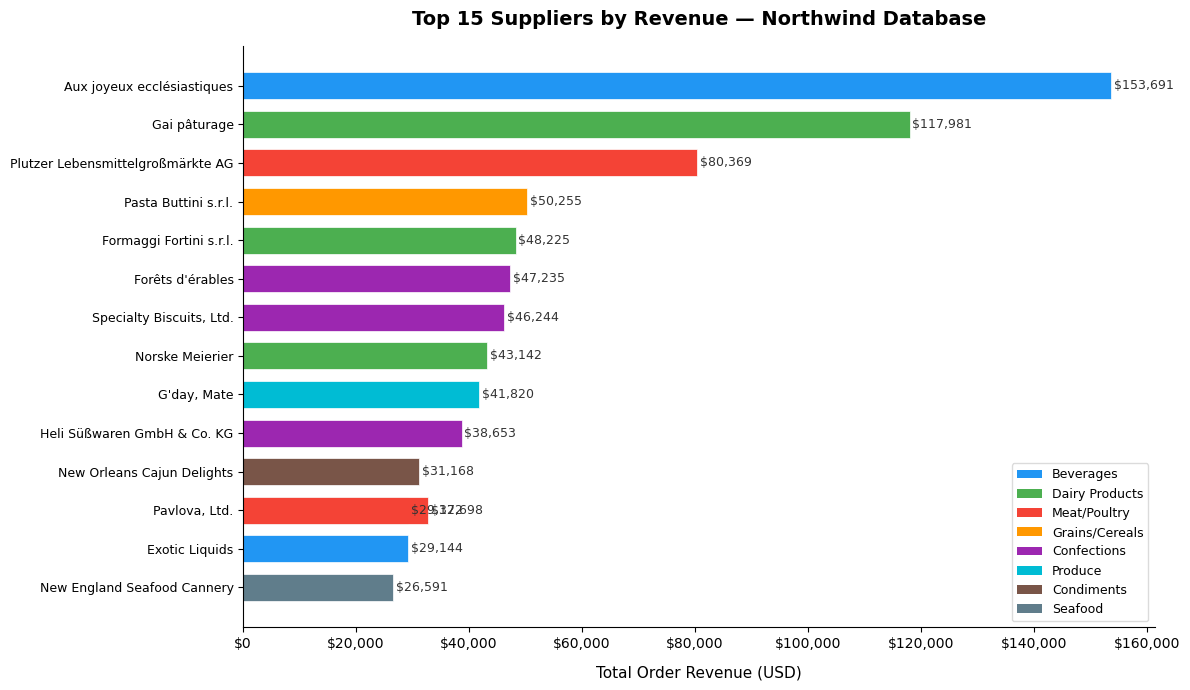

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))

# Take top 15 by revenue rank
top15 = supplier_ranking.head(15).sort_values("total_order_revenue", ascending=True)

# Color bars by category
categories = top15["CategoryName"].unique()
color_map = {
    "Beverages":      "#2196F3",
    "Dairy Products": "#4CAF50",
    "Meat/Poultry":   "#F44336",
    "Grains/Cereals": "#FF9800",
    "Confections":    "#9C27B0",
    "Produce":        "#00BCD4",
    "Condiments":     "#795548",
    "Seafood":        "#607D8B",
}
colors = top15["CategoryName"].map(color_map)

bars = ax.barh(
    top15["SupplierName"],
    top15["total_order_revenue"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

# Revenue labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333"
    )

# Formatting
ax.set_xlabel("Total Order Revenue (USD)", fontsize=11, labelpad=10)
ax.set_title("Top 15 Suppliers by Revenue — Northwind Database", fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

# Legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[cat], label=cat) for cat in color_map if cat in top15["CategoryName"].values]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.show()

A horizontal bar chart ranking the top 15 suppliers by total net revenue. Bars are color-coded by product category, revealing which categories dominate the top revenue positions and where supplier concentration is highest. Each bar is labeled with its exact dollar value.

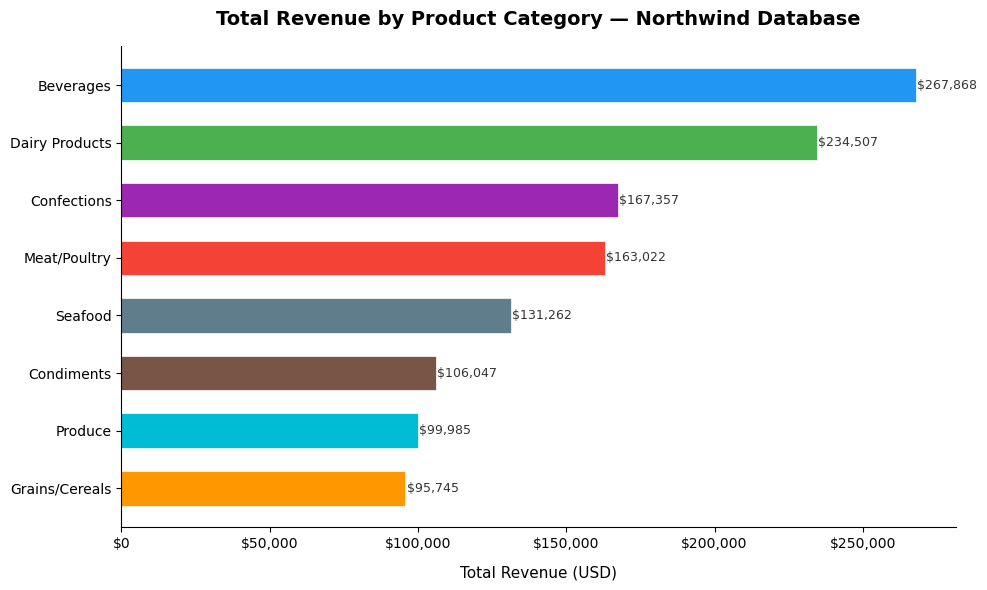

In [22]:
# ── Chart 2: Revenue by Category (aggregated) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

category_totals = (
    supplier_ranking
    .groupby("CategoryName")["total_order_revenue"]
    .sum()
    .sort_values(ascending=True)
)

colors_cat = [color_map.get(cat, "#999999") for cat in category_totals.index]

bars = ax.barh(
    category_totals.index,
    category_totals.values,
    color=colors_cat,
    edgecolor="white",
    linewidth=0.5,
    height=0.6
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333"
    )

ax.set_xlabel("Total Revenue (USD)", fontsize=11, labelpad=10)
ax.set_title("Total Revenue by Product Category — Northwind Database", fontsize=14, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig("outputs/01_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


The category-level view reveals structural revenue concentration, a handful of categories generate the bulk of Northwind's wholesale revenue, while others (such as Produce and Condiments) represent smaller but potentially strategic niche segments.

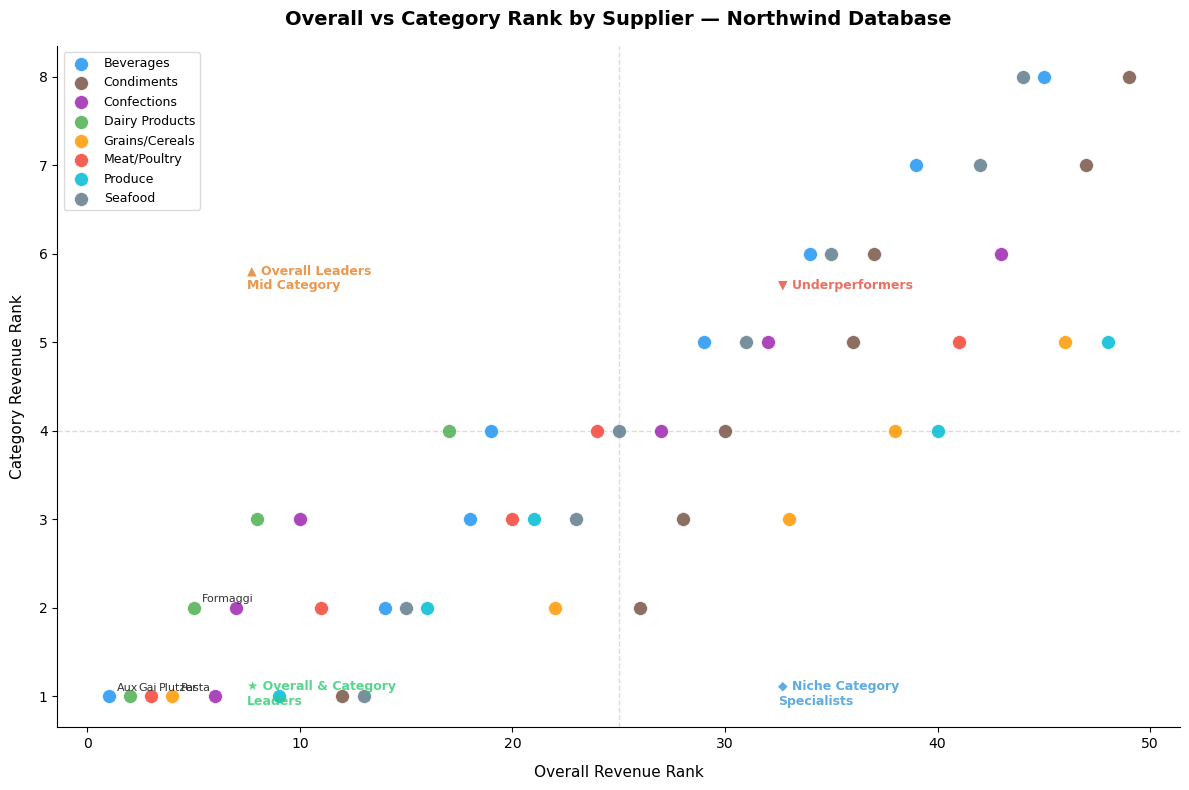

In [23]:
# ── Chart 3: Overall vs Category Rank — Quadrant Analysis ───────────────────
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate medians for quadrant lines
median_overall = supplier_ranking["revenue_rank"].median()
median_category = supplier_ranking["Category_rank"].median()

# Plot points colored by category
for cat, group in supplier_ranking.groupby("CategoryName"):
    ax.scatter(
        group["revenue_rank"],
        group["Category_rank"],
        label=cat,
        color=color_map.get(cat, "#999999"),
        s=100,
        alpha=0.85,
        edgecolors="white",
        linewidth=0.5,
        zorder=3
    )

# Draw quadrant lines
ax.axvline(x=median_overall, color="#cccccc", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
ax.axhline(y=median_category, color="#cccccc", linestyle="--", linewidth=1, alpha=0.7, zorder=1)

# Quadrant labels
ax.text(median_overall * 0.3, median_category * 0.3 - 0.3,
        "★ Overall & Category\nLeaders",
        fontsize=9, color="#2ecc71", fontweight="bold", alpha=0.8)
ax.text(median_overall * 1.3, median_category * 0.3 - 0.3,
        "◆ Niche Category\nSpecialists",
        fontsize=9, color="#3498db", fontweight="bold", alpha=0.8)
ax.text(median_overall * 0.3, median_category * 1.4,
        "▲ Overall Leaders\nMid Category",
        fontsize=9, color="#e67e22", fontweight="bold", alpha=0.8)
ax.text(median_overall * 1.3, median_category * 1.4,
        "▼ Underperformers",
        fontsize=9, color="#e74c3c", fontweight="bold", alpha=0.8)

# Annotate top 5 overall
for _, row in supplier_ranking[supplier_ranking["revenue_rank"] <= 5].iterrows():
    ax.annotate(
        row["SupplierName"].split()[0],
        (row["revenue_rank"], row["Category_rank"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
        color="#333333"
    )

ax.set_xlabel("Overall Revenue Rank", fontsize=11, labelpad=10)
ax.set_ylabel("Category Revenue Rank", fontsize=11, labelpad=10)
ax.set_title("Overall vs Category Rank by Supplier — Northwind Database",
             fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7, loc="upper left")

plt.tight_layout()
plt.savefig("outputs/01_rank_quadrant.png", dpi=150, bbox_inches="tight")
plt.show()


A scatter plot positioning every supplier at the intersection of their overall revenue rank (x-axis) and their within-category rank (y-axis). Median lines divide the chart into four quadrants. The top-5 overall suppliers are individually annotated.
 
| Quadrant | Label | Interpretation |
|---|---|---|
| Low overall rank, low category rank | ★ Overall & Category Leaders | Dominant performers across both dimensions — highest strategic value |
| High overall rank, low category rank | ◆ Niche Category Specialists | Lead their category but have lower total volume — valuable within segment |
| Low overall rank, high category rank | ▲ Overall Leaders, Mid Category | High total revenue but face strong competition within their category |
| High overall rank, high category rank | ▼ Underperformers | Lag on both dimensions — candidates for review |
 

 
 Suppliers in the Niche Category Specialist quadrant deserve targeted attention, they may be overlooked when ranked solely by total revenue, yet they represent dominant positions within their competitive segments.

## Section 2: Sales Trends Analysis
 
This section examines how revenue has evolved over the 23-month dataset (July 1996 – April 1998), identifies seasonal patterns, and measures the velocity and consistency of growth using month-over-month rates and a 3-month rolling average.
 
### Data Model
 
| Table | Role |
|---|---|
| `Orders` | OrderDate — anchors each transaction to a calendar month |
| `Order Details` | UnitPrice, Quantity, Discount — source of net revenue |
 
### Query Design — Window Functions
 
A single CTE (`MonthlySales`) aggregates net revenue per calendar month. Three window functions are then applied in the outer SELECT:
 
- `LAG(MonthlyRevenue, 1)` — retrieves the prior month's revenue for comparison
- **Month-over-Month Growth %** — computed as `(current − prior) / prior × 100`, with `NULLIF` guarding against division by zero
- `AVG() OVER (ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)` — produces the 3-month rolling average, smoothing short-term volatility


In [ ]:
-- USE Northwind;
-- GO

# -- Business question: How has monthly revenue trended?
# -- What is the month-over-month growth rate and 3-month rolling average?


WITH MonthlySales AS (
    SELECT
        DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1) AS SaleMonth,
        SUM(od.UnitPrice * od.Quantity * (1 - od.Discount))     AS MonthlyRevenue
    FROM Orders o
    JOIN [Order Details] od ON o.OrderID = od.OrderID
    WHERE o.OrderDate IS NOT NULL
    GROUP BY DATEFROMPARTS(YEAR(o.OrderDate), MONTH(o.OrderDate), 1)
)
SELECT
    SaleMonth,
    ROUND(MonthlyRevenue, 2)                                          AS MonthlyRevenue,
    ROUND(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 2)       AS PriorMonthRevenue,
    ROUND(
        (MonthlyRevenue - LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth))
        / NULLIF(LAG(MonthlyRevenue, 1) OVER (ORDER BY SaleMonth), 0) * 100
    , 1)                                                              AS MoMGrowthPct,
    ROUND(
        AVG(MonthlyRevenue) OVER (
            ORDER BY SaleMonth
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        )
    , 2)                                                              AS Rolling3MonthAvg
FROM MonthlySales
ORDER BY SaleMonth;

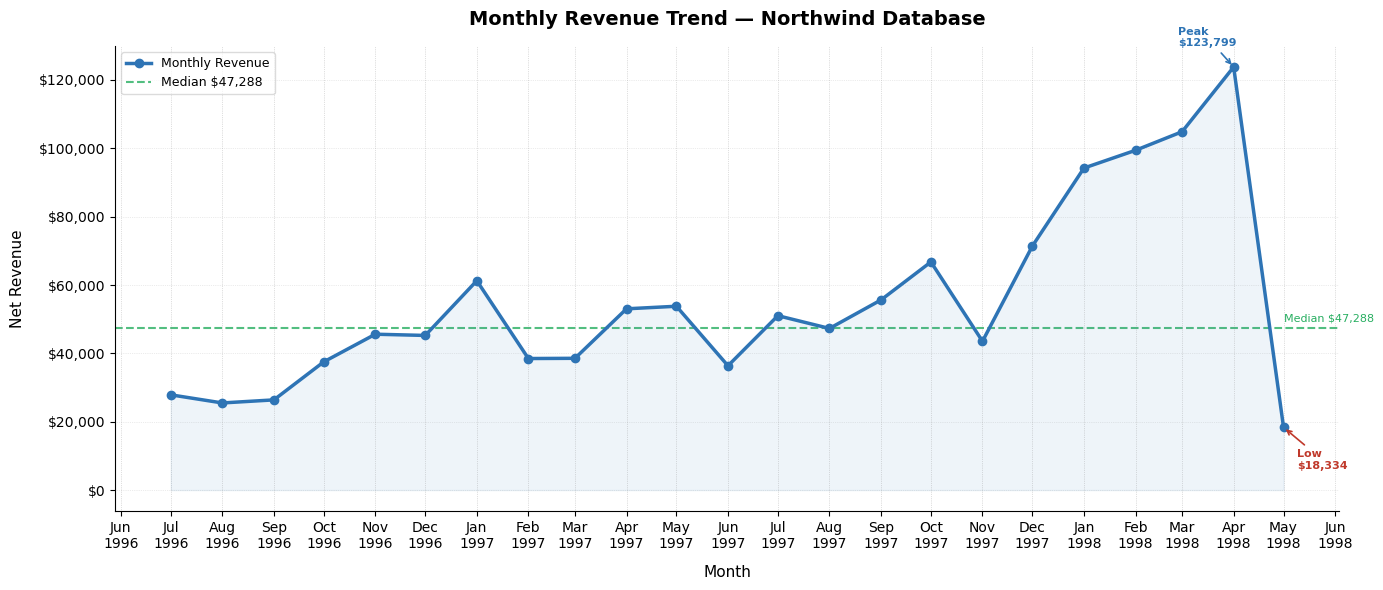

In [ ]:

sales_trends["SaleMonth"] = pd.to_datetime(sales_trends['SaleMonth'])
sales_trends =sales_trends.sort_values('SaleMonth')

fig, ax = plt.subplots(figsize=(14, 6))

median_overall = sales_trends["MonthlyRevenue"].median()
months = sales_trends["SaleMonth"]
revenue = sales_trends['MonthlyRevenue']

# Line + markers
ax.plot(months, revenue, 
        color='#2E74B5', 
        marker='o', 
        markersize=6, 
        linewidth=2.5, 
        label='Monthly Revenue',
        zorder=3)

# Median line
ax.axhline(y=median_overall, 
           color="#27AE60", 
           linestyle="--", 
           linewidth=1.5, 
           alpha=0.8, 
           zorder=1, 
           label=f'Median ${median_overall:,.0f}')

# Subtle vertical grid — helps trace each point to its month
ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.5, color='gray')
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')

# Every month on X axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Y axis currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'
))

# Peak annotation
peak_idx = sales_trends['MonthlyRevenue'].idxmax()
peak_row = sales_trends.loc[peak_idx]
ax.annotate(f"Peak\n${peak_row['MonthlyRevenue']:,.0f}",
            xy=(peak_row['SaleMonth'], peak_row['MonthlyRevenue']),
            xytext=(-40, 15),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            color='#2E74B5',
            arrowprops=dict(arrowstyle='->', color='#2E74B5', lw=1.2))

# Low annotation
low_idx = sales_trends['MonthlyRevenue'].idxmin()
low_row = sales_trends.loc[low_idx]
ax.annotate(f"Low\n${low_row['MonthlyRevenue']:,.0f}",
            xy=(low_row['SaleMonth'], low_row['MonthlyRevenue']),
            xytext=(10, -30),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Net Revenue", fontsize=11, labelpad=10)
ax.set_title("Monthly Revenue Trend — Northwind Database",
             fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7, loc="upper left")

ax.text(months.iloc[-1], median_overall + 1500, 
        f'Median ${median_overall:,.0f}', 
        fontsize=8, color='#27AE60', va='bottom')
ax.fill_between(months, revenue, alpha=0.08, color='#2E74B5')

plt.tight_layout()
plt.savefig("outputs/02_Monthly_Revenue.png", dpi=150, bbox_inches="tight")
plt.show()


Monthly revenue grew consistently from $27861 in July-96 to $123,799 in April-98 a ~4.44x increase over 23 months. The median monthly revenue of $47,288 was first exceeded in Jan-97 of 24 months, with the second half of the dataset showing notably stronger and more sustained performance above the median line.

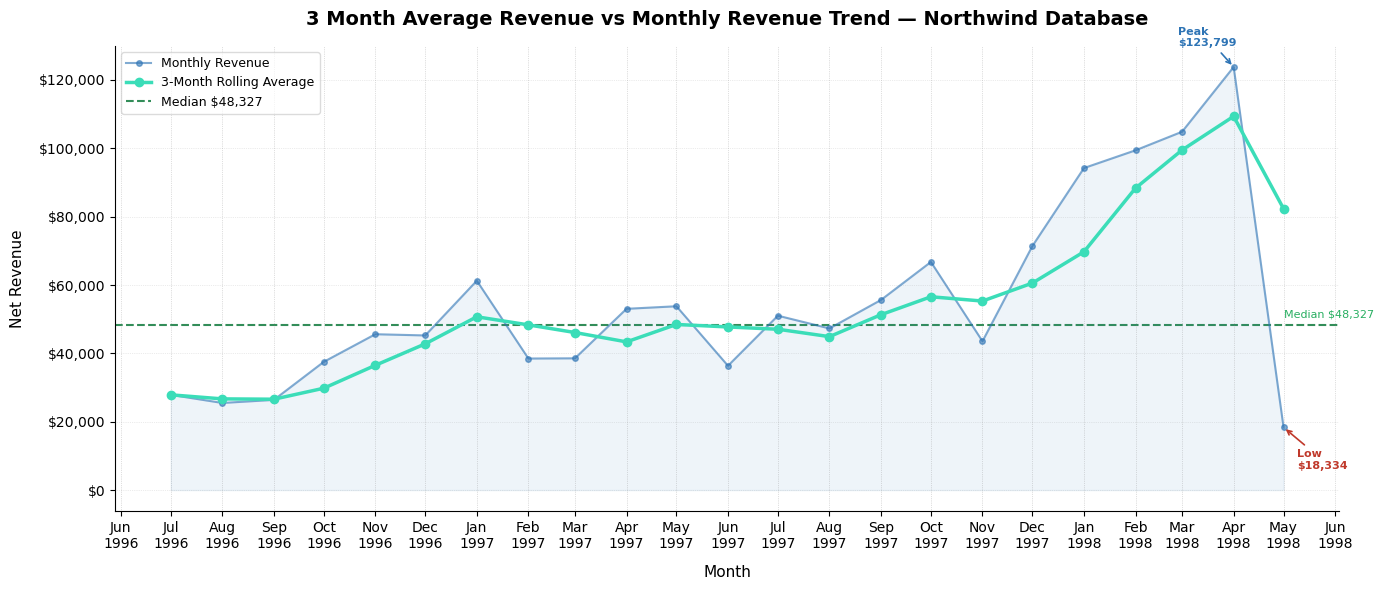

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

months = sales_trends['SaleMonth']
three_month_average = sales_trends['Rolling3MonthAvg']
revenue = sales_trends['MonthlyRevenue']
median_overall = sales_trends["Rolling3MonthAvg"].median()


# Monthly Revenue — thinner, more transparent
ax.plot(months, revenue,
        color='#2E74B5',
        marker='o',
        markersize=4,
        linewidth=1.5,
        alpha=0.6,
        label='Monthly Revenue',
        zorder=2)

# Rolling Average — thicker, more prominent
ax.plot(months, three_month_average,
        color='#3BDDB8',
        marker='o',
        markersize=6,
        linewidth=2.5,
        label='3-Month Rolling Average',
        zorder=3)

# Median line
ax.axhline(y=median_overall, 
           color="#00712F", 
           linestyle="--", 
           linewidth=1.5, 
           alpha=0.8, 
           zorder=1, 
           label=f'Median ${median_overall:,.0f}')

# Subtle vertical grid — helps trace each point to its month
ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.5, color='gray')
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')

# Every month on X axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Y axis currency
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'${x:,.0f}'
))

# Peak annotation
peak_idx = sales_trends['MonthlyRevenue'].idxmax()
peak_row = sales_trends.loc[peak_idx]
ax.annotate(f"Peak\n${peak_row['MonthlyRevenue']:,.0f}",
            xy=(peak_row['SaleMonth'], peak_row['MonthlyRevenue']),
            xytext=(-40, 15),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            color='#2E74B5',
            arrowprops=dict(arrowstyle='->', color='#2E74B5', lw=1.2))

# Low annotation
low_idx = sales_trends['MonthlyRevenue'].idxmin()
low_row = sales_trends.loc[low_idx]
ax.annotate(f"Low\n${low_row['MonthlyRevenue']:,.0f}",
            xy=(low_row['SaleMonth'], low_row['MonthlyRevenue']),
            xytext=(10, -30),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("Net Revenue", fontsize=11, labelpad=10)
ax.set_title("3 Month Average Revenue vs Monthly Revenue Trend — Northwind Database",
             fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7, loc="upper left")

ax.text(months.iloc[-1], median_overall + 1500, 
        f'Median ${median_overall:,.0f}', 
        fontsize=8, color='#27AE60', va='bottom')
ax.fill_between(months, revenue, alpha=0.08, color='#2E74B5')


plt.tight_layout()
plt.savefig("outputs/02_Rolling3MonthAverage.png", dpi=150, bbox_inches="tight")
plt.show()

The 3-month rolling average reveals the underlying revenue trend beneath month-to-month volatility. The most significant divergence occurred in September-94 when monthly revenue exceeded the rolling average with historic highs signaling an unusually strong period relative to recent trend. 

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


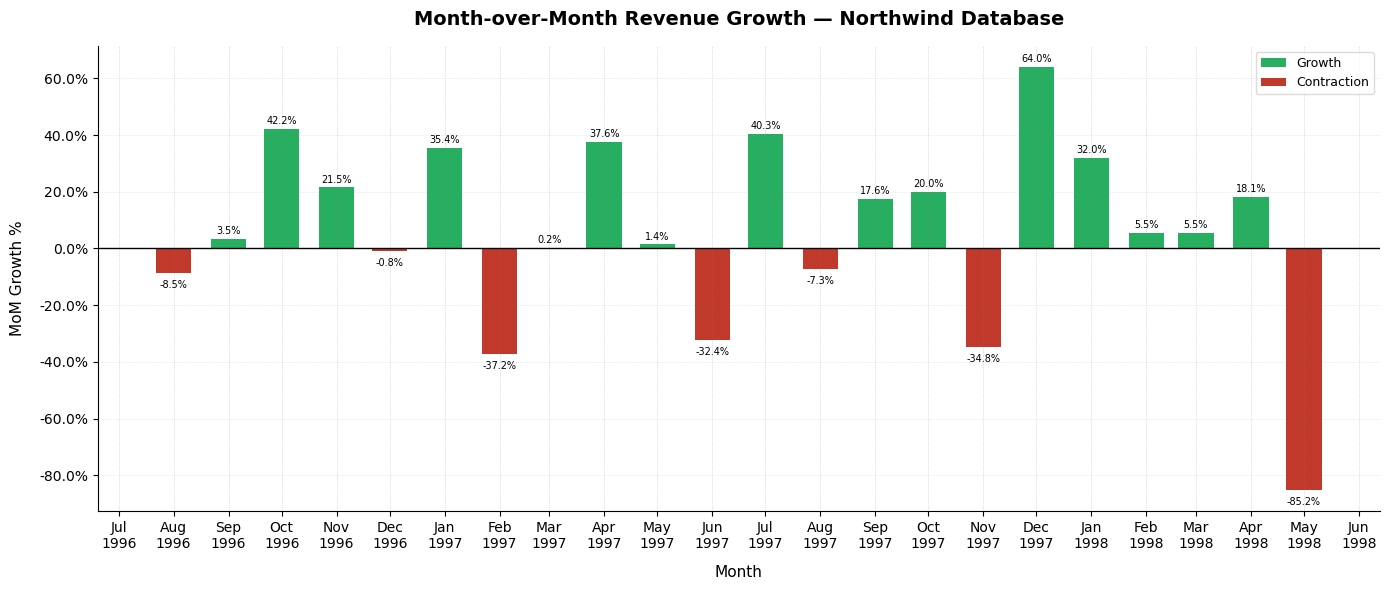

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

months = sales_trends["SaleMonth"]
growth = sales_trends["MoMGrowthPct"]

colors = ['#27AE60' if x > 0 else '#C0392B'
                  for x in sales_trends["MoMGrowthPct"]]

ax.bar(months,
       growth,
       color= colors,
       width=20)

ax.axhline(y=0, color='black', linewidth=1, zorder=2)

# Every month on X axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

# Subtle vertical grid — helps trace each point to its month
ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.5, color='gray')
ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, p: f'{x:.1f}%'
))
ax.set_xlabel("Month", fontsize=11, labelpad=10)
ax.set_ylabel("MoM Growth %", fontsize=11, labelpad=10)
ax.set_title("Month-over-Month Revenue Growth — Northwind Database",
             fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_elements = [
    Patch(facecolor='#27AE60', label='Growth'),
    Patch(facecolor='#C0392B', label='Contraction')
]

ax.legend(handles=legend_elements, fontsize=9, 
          framealpha=0.7, loc="upper right")


for bar, value in zip(ax.patches, growth):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (1 if value > 0 else -2.5),
        f'{value:.1f}%',
        ha='center',
        va='bottom' if value > 0 else 'top',
        fontsize=7,
        color='black'
    )

plt.tight_layout()
plt.savefig("outputs/02_MoM_Growth.png", dpi=150, bbox_inches="tight")
plt.show()

Of the 23 months analyzed, 15 showed positive growth and 8 showed contraction. The strongest single-month acceleration was Dec-97 at +64%, while the sharpest contraction occurred in May-98 at -85%.

In [ ]:
-- USE Northwind;
-- GO

WITH ShipperDetails AS (
	SELECT 
		s.ShipperID, 
		s.CompanyName,
		COUNT(DISTINCT o.OrderID) AS OrderCount,
		ROUND(AVG(CAST(DATEDIFF(DAY, o.OrderDate, o.ShippedDate) AS FLOAT)),1) AS AvgDaysToShip,
		SUM(CASE WHEN o.ShippedDate <= RequiredDate THEN 1 ELSE 0 END) AS OnTimeOrders,
		ROUND(100 * SUM(CASE WHEN o.ShippedDate <= o.RequiredDate THEN 1 ELSE 0 END) /NULLIF(COUNT(o.OrderID),0),2) AS OnTimePct,
		ROUND(100 * SUM(CASE WHEN o.ShippedDate > RequiredDate THEN 1 ELSE 0 END) /NULLIF(COUNT(o.OrderID),0),2) AS LatePct,
		AVG(o.Freight) AS AvgFreightExp,
		SUM(o.Freight) AS TotalSpentPerShipper
	FROM Shippers AS s
	JOIN Orders AS o
		ON s.ShipperID = o.ShipVia
	GROUP BY s.ShipperID, s.CompanyName
)
SELECT *
FROM ShipperDetails
ORDER BY AvgDaysToShip

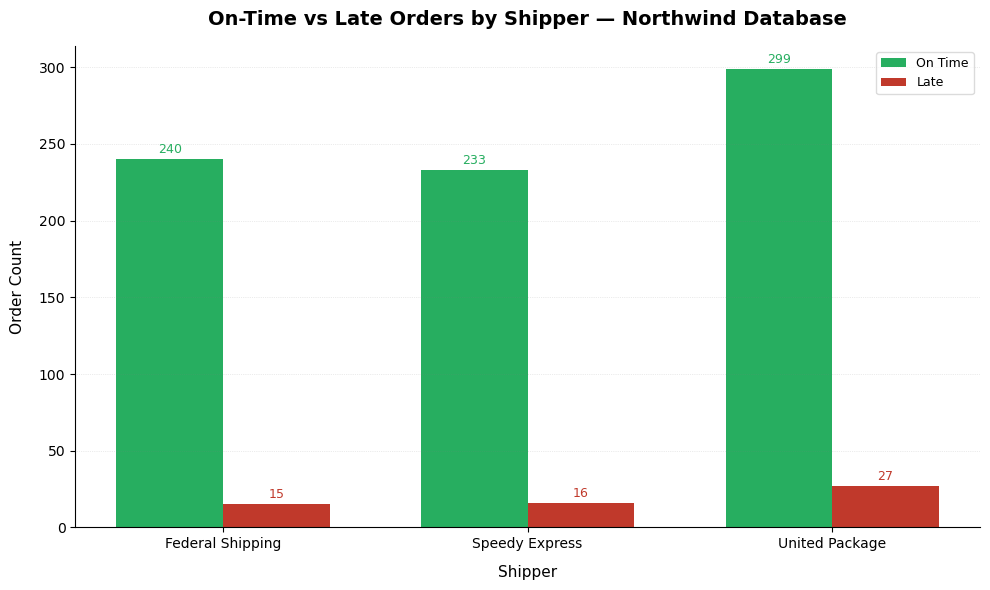

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

companies = fulfillment['CompanyName']
on_time = fulfillment['OnTimeOrders']
late_orders = fulfillment['OrderCount'] - fulfillment['OnTimeOrders']

x = np.arange(len(companies))
width = 0.35

bars_on = ax.bar(x - width/2, on_time, width,
                 label='On Time', color='#27AE60')
bars_late = ax.bar(x + width/2, late_orders, width,
                   label='Late', color='#C0392B')

# Value labels on bars
for bar in bars_on:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=9, color='#27AE60')

for bar in bars_late:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=9, color='#C0392B')

ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(companies)
ax.set_xlabel("Shipper", fontsize=11, labelpad=10)
ax.set_ylabel("Order Count", fontsize=11, labelpad=10)
ax.set_title("On-Time vs Late Orders by Shipper — Northwind Database",
             fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig("outputs/03_ontime_vs_late.png", dpi=150, bbox_inches="tight")
plt.show()

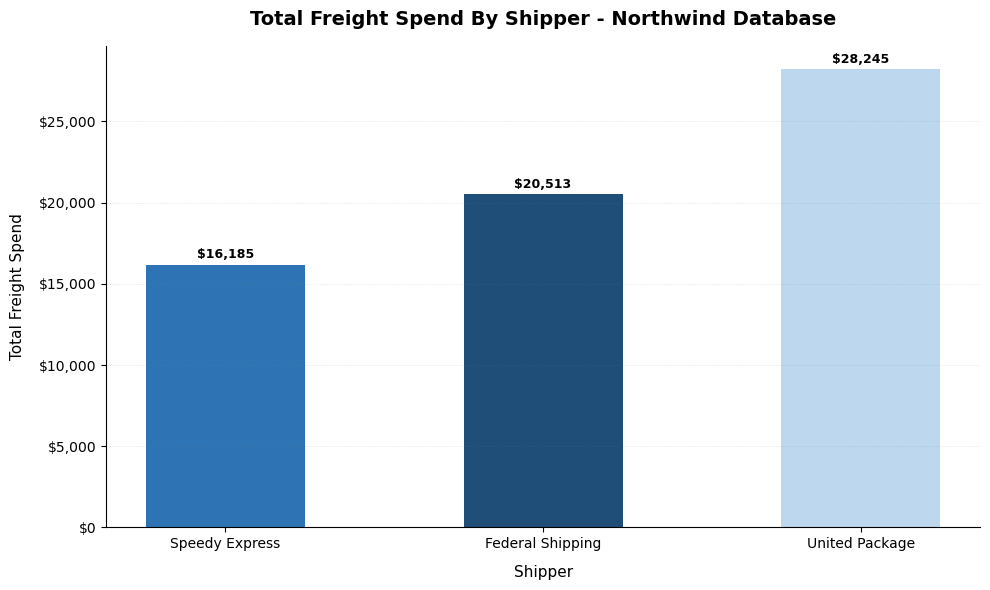

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Color bars by company
companies = fulfillment['CompanyName'].unique()
color_map = {
    'Federal Shipping': "#1F4E79",
    'Speedy Express':   "#2E74B5",
    'United Package':   "#BDD7EE"
}

fulfillment_sorted = fulfillment.sort_values('TotalSpentPerShipper', ascending=True)

companies = fulfillment_sorted['CompanyName']
spending = fulfillment_sorted['TotalSpentPerShipper']
colors = fulfillment_sorted['CompanyName'].map(color_map)

bars = ax.bar(
    companies,
    spending,
    color=colors,
    width=0.5)

# Value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'${bar.get_height():,.0f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
            )

ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
ax.set_xlabel("Shipper", fontsize=11, labelpad=10)
ax.set_ylabel("Total Freight Spend", fontsize=11, labelpad=10)
ax.set_title("Total Freight Spend By Shipper - Northwind Database", fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/03_freight_by_shipper.png", dpi=150, bbox_inches="tight")
plt.show()

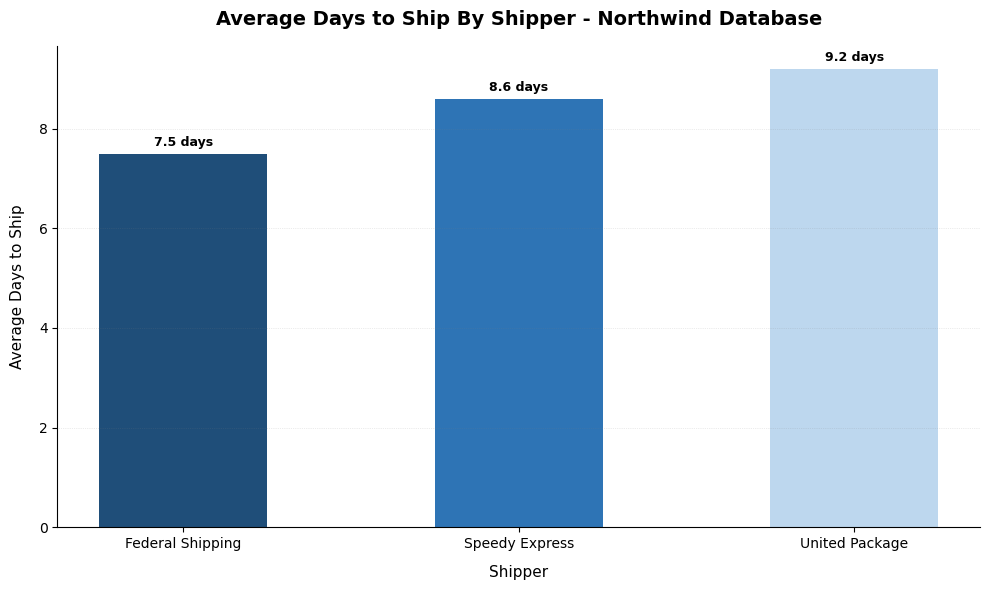

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

# Color bars by company
companies = fulfillment['CompanyName'].unique()
color_map = {
    'Federal Shipping': "#1F4E79",
    'Speedy Express':   "#2E74B5",
    'United Package':   "#BDD7EE"
}

fulfillment_sorted = fulfillment.sort_values('AvgDaysToShip', ascending=True)

companies = fulfillment_sorted['CompanyName']
shipping = fulfillment_sorted['AvgDaysToShip']
colors = fulfillment_sorted['CompanyName'].map(color_map)


bars = ax.bar(
    companies,
    shipping,
    color=colors,
    width=0.5)

# Value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():,.1f} days',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
            )

ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
ax.set_xlabel("Shipper", fontsize=11, labelpad=10)
ax.set_ylabel("Average Days to Ship", fontsize=11, labelpad=10)
ax.set_title("Average Days to Ship By Shipper - Northwind Database", fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/03_avg_time_to_ship.png", dpi=150, bbox_inches="tight")
plt.show()

Speedy Express is the fastest shipper at 7.5 days average that is 1.7 days faster than United Package at 9.2 days, an 18% difference. Federal Shipping falls between at 8.6 days. While the gap between shippers is relatively narrow, for time-sensitive orders the choice of carrier has meaningful impact on customer experience. Notably, United Package handles the highest order volume (326 orders) despite having both the slowest average ship time and the lowest on-time rate, suggesting capacity constraints may be affecting performance.

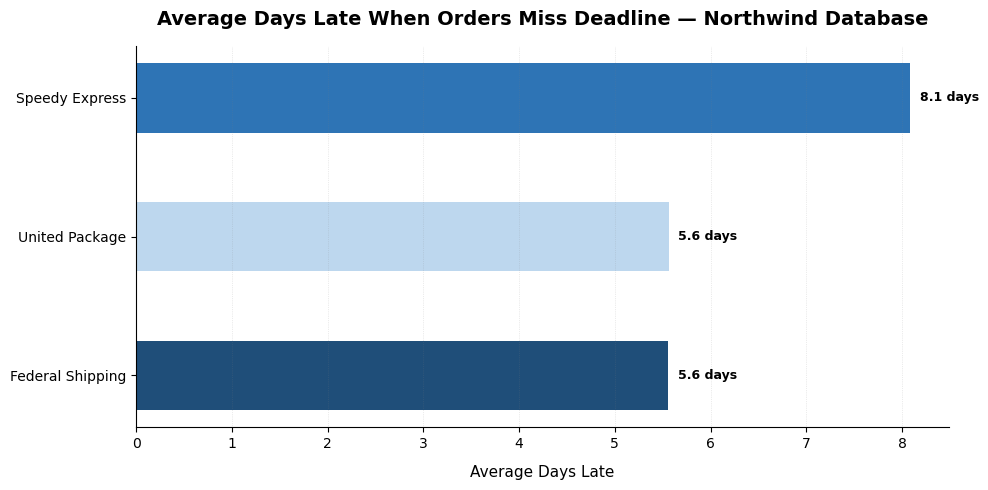

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

late_by_shipper = order_timing.groupby('CompanyName').agg(
    late_count=('OrderID', 'count'),
    avg_days_late=('DaysLate', 'mean'),
    max_days_late=('DaysLate', 'max')
).reset_index().sort_values('avg_days_late', ascending=False)


late_sorted = late_by_shipper.sort_values('avg_days_late', ascending=True)

color_map = {
    'Federal Shipping': "#1F4E79",
    'Speedy Express':   "#2E74B5",
    'United Package':   "#BDD7EE"
}

colors = late_sorted['CompanyName'].map(color_map)

bars = ax.barh(late_sorted['CompanyName'],
               late_sorted['avg_days_late'],
               color=colors,
               height=0.5)

# Value labels
for bar in bars:
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f} days',
            va='center', fontsize=9, fontweight='bold')

ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.3, color='gray')
ax.set_xlabel("Average Days Late", fontsize=11, labelpad=10)
ax.set_title("Average Days Late When Orders Miss Deadline — Northwind Database",
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/04_avg_days_late_by_shipper.png", dpi=150, bbox_inches="tight")
plt.show()

While Chart "On Time VS Late Orders by Shippers"  identified United Package as having the lowest on-time rate with 27 late orders, the most of any shipper Chart "Average Days Late When Orders Miss Deadline" reveals a more nuanced picture of delay severity. Speedy Express, despite fewer late orders (15), averages 8.1 days past the required date when delays do occur 45% more severe than United Package and Federal Shipping, both averaging 5.6 days late. Federal Shipping performs most consistently across all three metrics: fewest late orders (15), tied for lowest average delay (5.6 days), and the best on-time rate from Chart 8. The data suggests two distinct failure modes, United Package fails frequently but recovers quickly, while Speedy Express fails rarely but severely. For time-critical shipments, Federal Shipping is the lowest-risk carrier across all fulfillment dimensions.